# 03 — Baseline Models

This notebook trains baseline classifiers for `Crime Solved` and compares them on the validation set:
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

It saves the best-performing baseline pipeline under `models/`.


In [4]:
# Setup + load engineered splits
from pathlib import Path
import sys

import pandas as pd

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import DataPaths, load_processed_split
from src.train import TrainConfig, dataframe_X_y, fit_pipeline, make_pipeline, save_model
from src.evaluate import evaluate_binary, plot_confusion, plot_roc_curve

paths = DataPaths.from_project_root(PROJECT_ROOT)

train_df = load_processed_split(paths.processed_dir, "train")
val_df = load_processed_split(paths.processed_dir, "val")
test_df = load_processed_split(paths.processed_dir, "test")

X_train, y_train = dataframe_X_y(train_df)
X_val, y_val = dataframe_X_y(val_df)
X_test, y_test = dataframe_X_y(test_df)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

cfg = TrainConfig(random_state=42, n_jobs=-1)
MODELS = ["logreg", "rf", "xgb", "lgb"]

Train: (446917, 31) (446917,)
Val: (95768, 31) (95768,)
Test: (95769, 31) (95769,)


In [2]:
# Train + validate
results = []
trained = {}

for name in MODELS:
    print("\n====", name, "====")
    pipe = make_pipeline(X_train, name, cfg=cfg)
    pipe = fit_pipeline(pipe, X_train, y_train)

    val_res = evaluate_binary(pipe, X_val, y_val)
    print("Val ROC-AUC:", round(val_res.roc_auc, 4))
    print("Val F1 (pos=1):", round(val_res.report.get("1", {}).get("f1-score", 0.0), 4))

    results.append(
        {
            "model": name,
            "val_roc_auc": val_res.roc_auc,
            "val_f1_pos": val_res.report.get("1", {}).get("f1-score", 0.0),
        }
    )
    trained[name] = pipe

results_df = pd.DataFrame(results).sort_values("val_roc_auc", ascending=False)
results_df


==== logreg ====


c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values

Val ROC-AUC: 1.0
Val F1 (pos=1): 0.9997

==== rf ====


c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values

Val ROC-AUC: 1.0
Val F1 (pos=1): 0.9996

==== xgb ====


...

c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 313720, number of negative: 133197
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6285
[LightGBM] [Info] Number of data points in the train set: 446917, number of used features: 2651
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.701965 -> initscore=0.856672
[LightGBM] [Info] Start training from score 0.856672


c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Val ROC-AUC: 1.0
Val F1 (pos=1): 0.9996


,model,val_roc_auc,val_f1_pos
2,xgb,0.999991,0.999650
3,lgb,0.999987,0.999628
0,logreg,0.999968,0.999717
1,rf,0.999953,0.999591


Best (by val ROC-AUC): xgb


c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Test ROC-AUC: 1.0
              precision    recall  f1-score       support
0              0.999264  0.999439  0.999352  28543.000000
1              0.999762  0.999688  0.999725  67226.000000
accuracy       0.999614  0.999614  0.999614      0.999614
macro avg      0.999513  0.999564  0.999538  95769.000000
weighted avg   0.999614  0.999614  0.999614  95769.000000


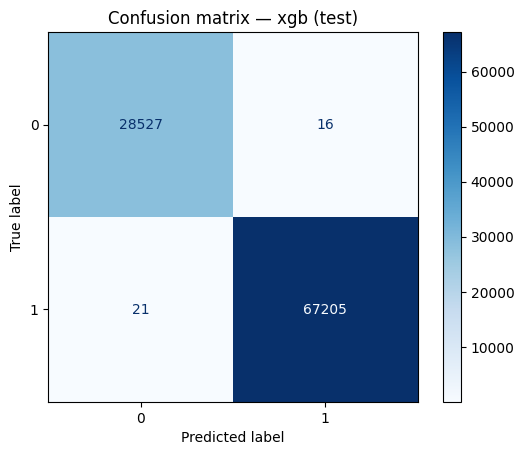

c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


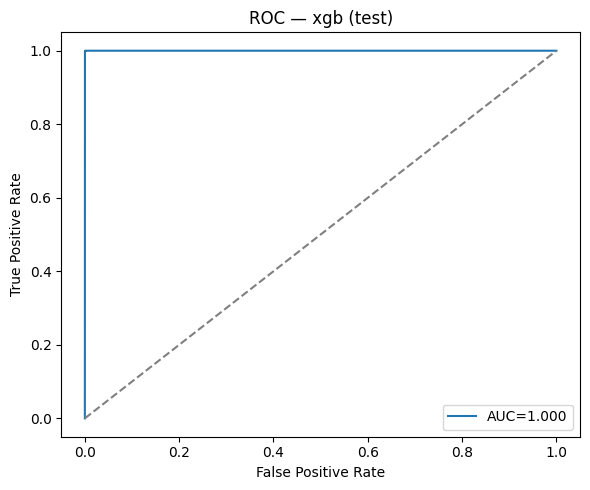

Saved: c:\Users\Wassim Rahali\Desktop\Crime IA\models\xgb_baseline.joblib


c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,Victim Race,n,roc_auc
0,Black,45047,1.000000
1,White,47490,0.999998


In [3]:
# Evaluate best model on test + save
best_name = results_df.iloc[0]["model"]
best_pipe = trained[best_name]

print("Best (by val ROC-AUC):", best_name)

test_res = evaluate_binary(best_pipe, X_test, y_test)
print("Test ROC-AUC:", round(test_res.roc_auc, 4))
print(pd.DataFrame(test_res.report).T[["precision", "recall", "f1-score", "support"]])

plot_confusion(test_res.confusion, title=f"Confusion matrix — {best_name} (test)")
plot_roc_curve(best_pipe, X_test, y_test, title=f"ROC — {best_name} (test)")

# Save pipeline
model_path = PROJECT_ROOT / "models" / f"{best_name}_baseline.joblib"
save_model(best_pipe, model_path)
print("Saved:", model_path)

# Bias audit quick check: ROC-AUC by Victim Race (if enough samples)
from src.evaluate import group_metrics_by_column, predict_proba_positive

proba_test = predict_proba_positive(best_pipe, X_test)
audit_df = test_df.reset_index(drop=True)

by_race = group_metrics_by_column(
    df_with_target=audit_df,
    y_true=y_test,
    y_proba=proba_test,
    group_col="Victim Race",
    min_group_size=5000,
)
by_race.head(15)